In [1]:
import sys
!{sys.executable} -m pip install seaborn

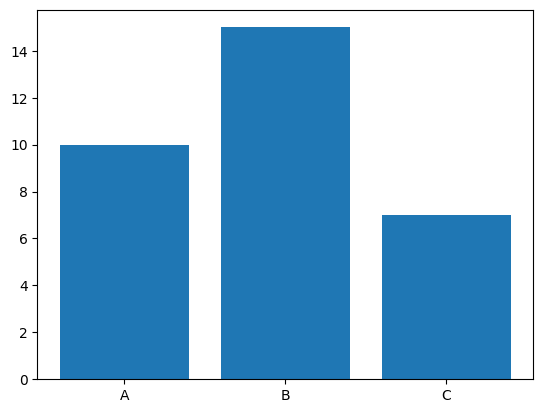

In [2]:
import matplotlib.pyplot as plt
plt.bar(['A', 'B', 'C'], [10, 15, 7])
plt.show()

<Axes: >

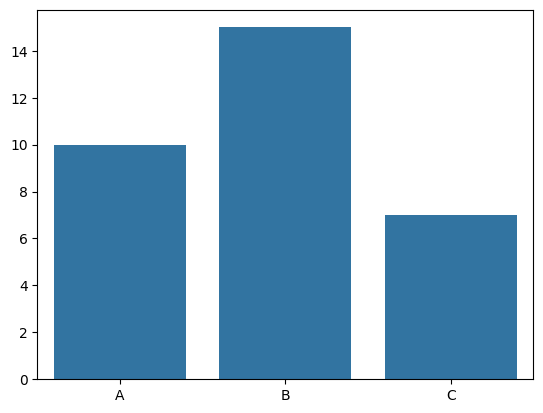

In [3]:
import seaborn as sns
sns.barplot(x=['A', 'B', 'C'], y=[10, 15, 7])

### Seaborn과 Matplotlib을 사용하여 데이터 표현

In [9]:
# 1. 예제 데이터셋 불러오기
tips = sns.load_dataset("tips")

# 2. 상위 5개 행 미리보기
print(tips.head())

# 3. 전체 행/열 크기 확인
print("\nShape:", tips.shape)  # (행 수, 열 수)

# 4. 열 이름과 데이터 타입 확인
print("\nColumn Info:")
print(tips.info())

# 5. 기술 통계 요약 (수치형 변수)
print("\nDescriptive Statistics:")
print(tips.describe())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Shape: (244, 7)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None

Descriptive Statistics:
       total_bill         tip        size
count  244.000000  244.00000

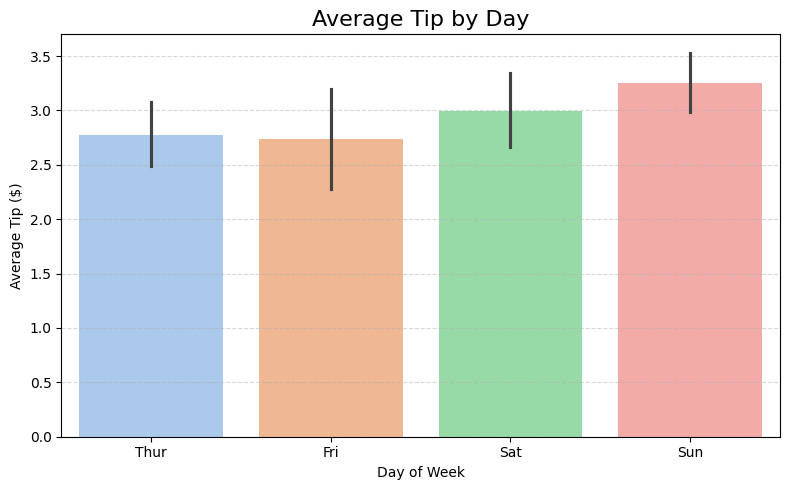

In [10]:
# 6. Seaborn barplot 그리기
plt.figure(figsize=(8, 5))
sns.barplot(data=tips, x="day", y="tip", hue="day", estimator='mean', 
            palette='pastel', legend=False)

plt.title("Average Tip by Day", fontsize=16)
plt.xlabel("Day of Week")
plt.ylabel("Average Tip ($)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
type(tips)

pandas.core.frame.DataFrame

In [14]:
tips[tips['sex'] == 'Female']        # 여성만

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
11,35.26,5.00,Female,No,Sun,Dinner,4
14,14.83,3.02,Female,No,Sun,Dinner,2
16,10.33,1.67,Female,No,Sun,Dinner,3
...,...,...,...,...,...,...,...
226,10.09,2.00,Female,Yes,Fri,Lunch,2
229,22.12,2.88,Female,Yes,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2


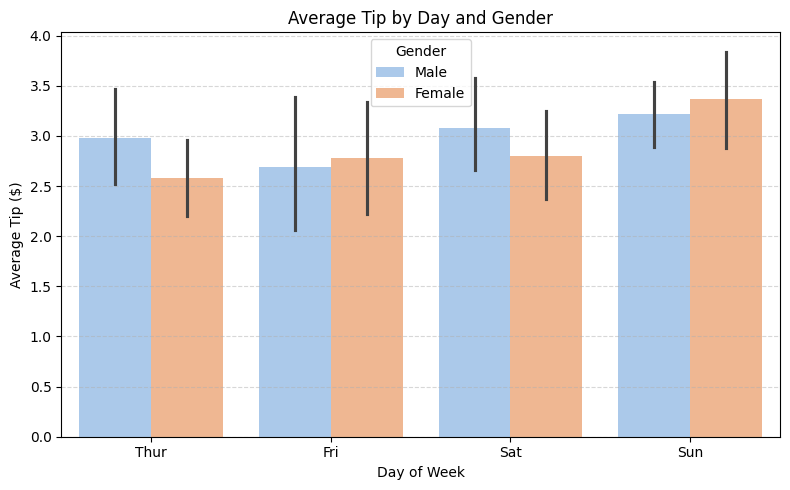

In [17]:
# 요일별 성별 평균 팁 시각화
plt.figure(figsize=(8, 5))
sns.barplot(data=tips, x='day', y='tip', hue='sex', estimator='mean', palette='pastel')

plt.title('Average Tip by Day and Gender')
plt.xlabel('Day of Week')
plt.ylabel('Average Tip ($)')
plt.legend(title='Gender', loc=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 누락 데이터 처리

In [41]:
# titanic 데이터셋 가져오기
df = sns.load_dataset('titanic')

# 첫 5행 출력
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [22]:
# 데이터프레임 개요
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [23]:
# deck 열의 NaN 개수 계산하기
df['deck'].value_counts(dropna=False) 

deck
NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4
Name: count, dtype: int64

### 시각적으로 NaN 확인

In [26]:
import sys
!{sys.executable} -m pip install missingno

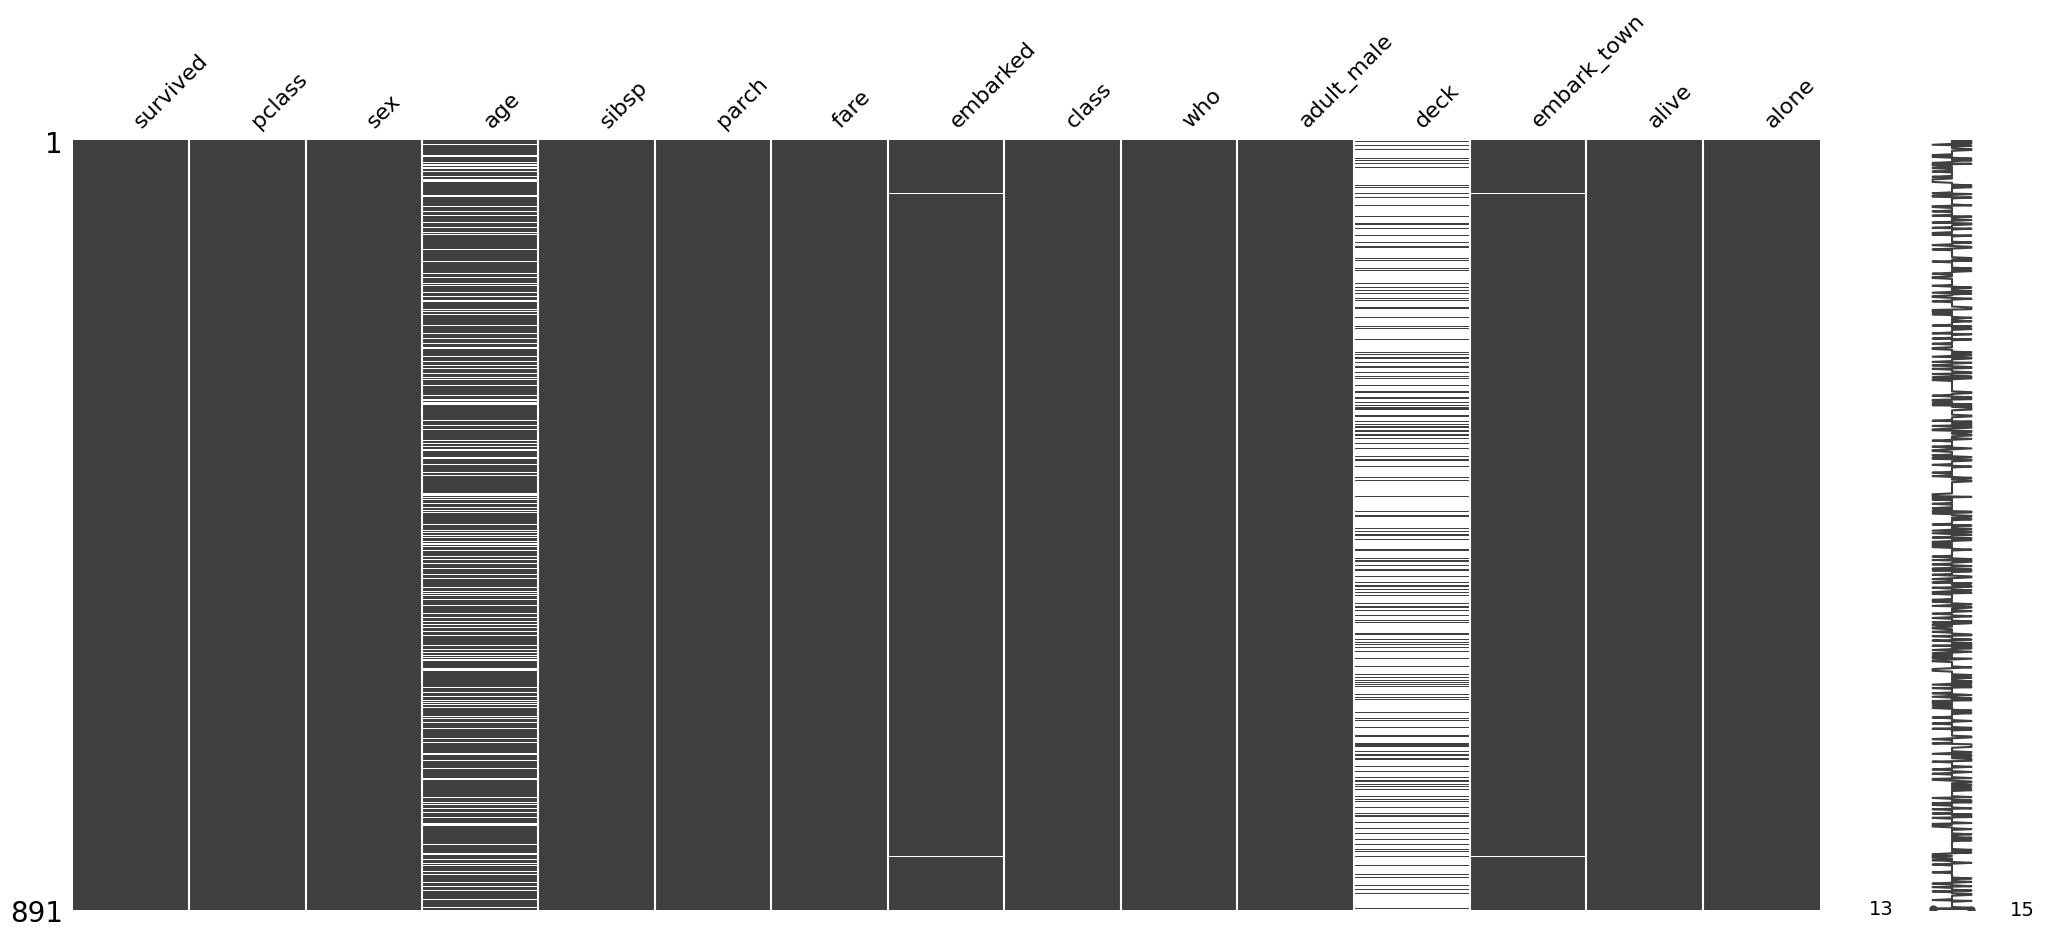

In [27]:
# missingno 라이브러리 활용
import missingno as msno
import matplotlib.pyplot as plt

# 매트릭스 그래프
msno.matrix(df)
plt.show()

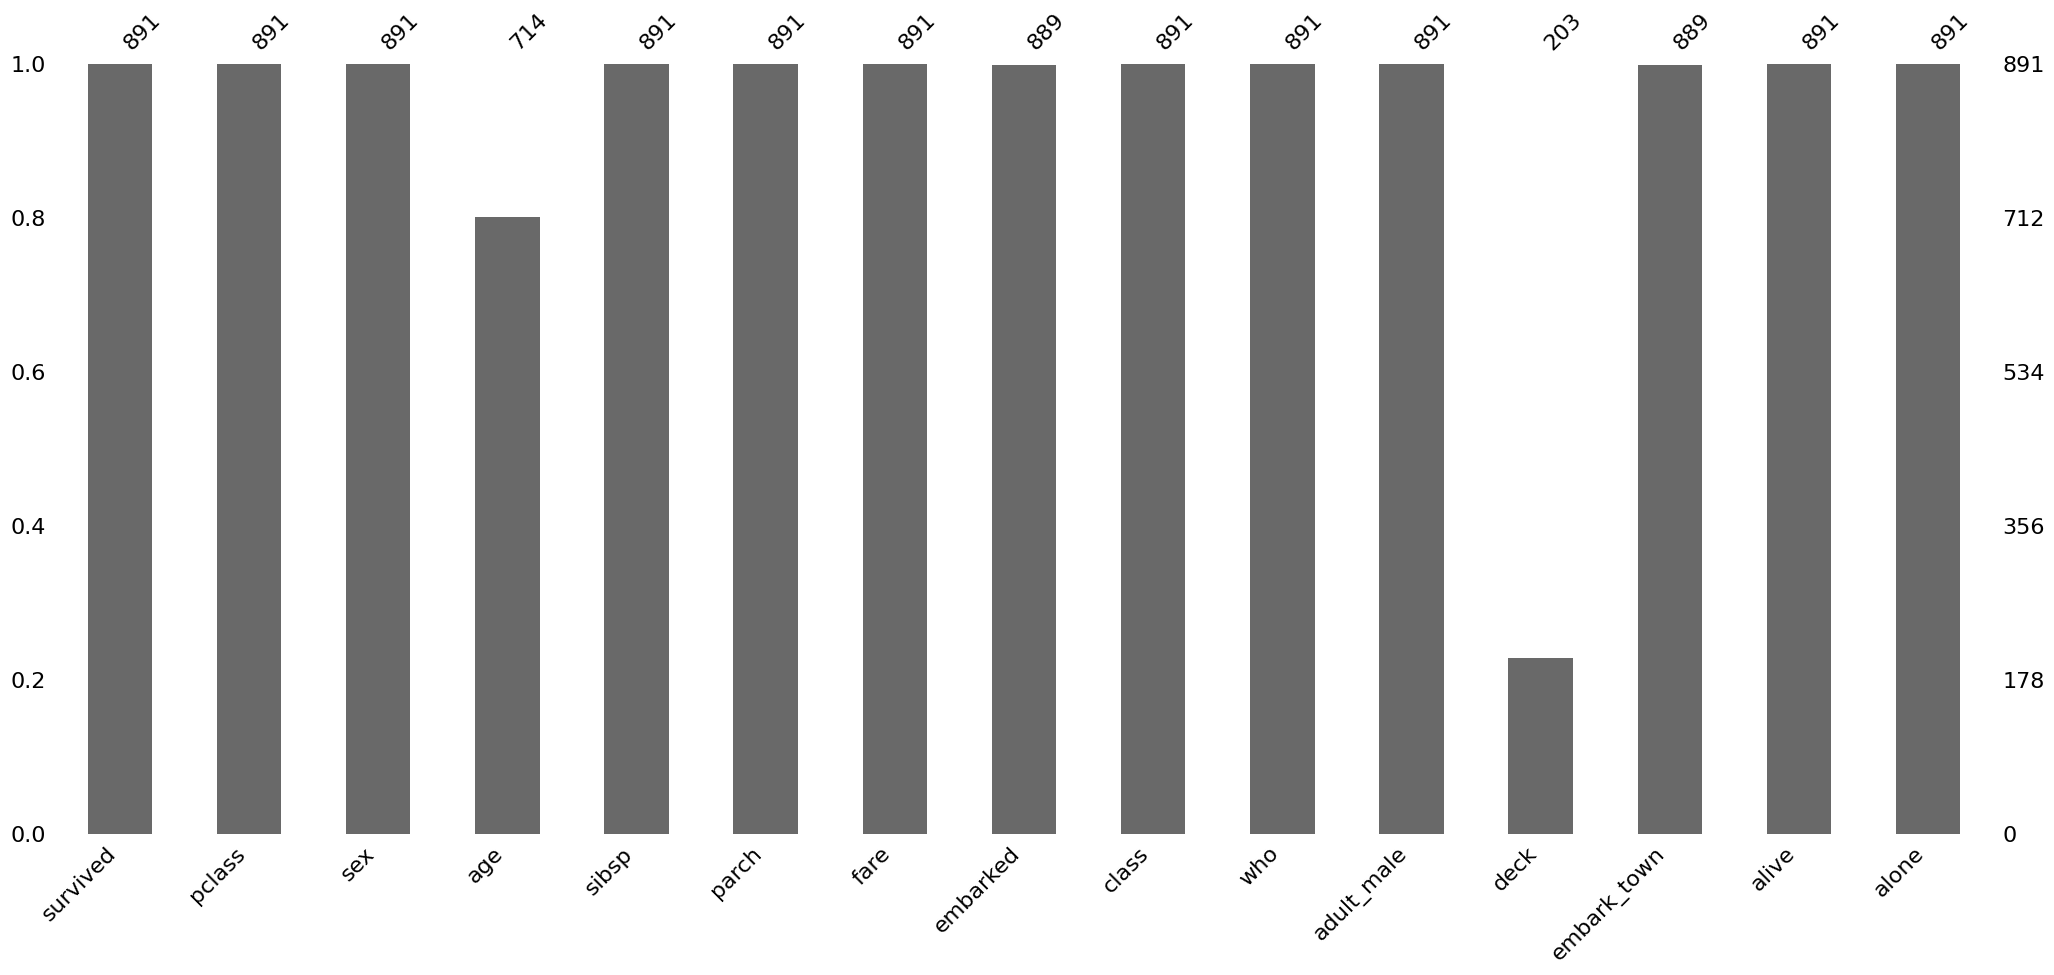

In [28]:
# 막대 그래프
msno.bar(df)
plt.show()

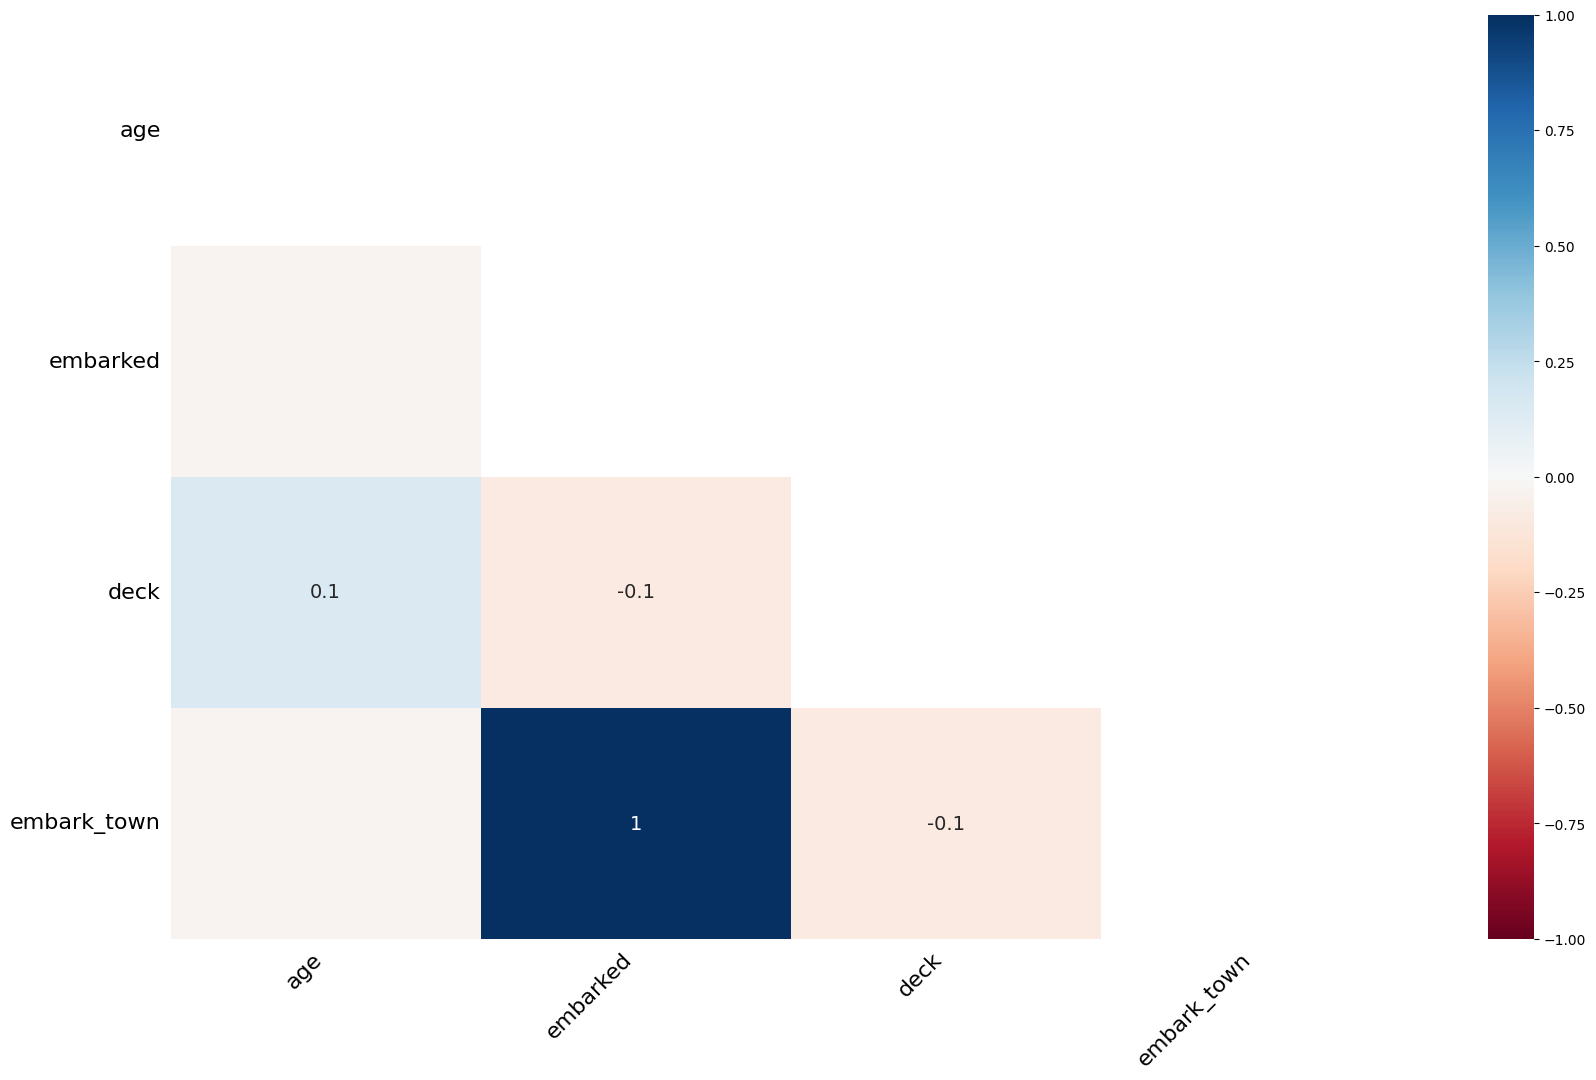

In [29]:
# 히트맵 
msno.heatmap(df)
plt.show()

In [30]:
# isnull() 메서드를 합계로 집계하여 각 열의 NaN 개수 계산하기
df.isnull().sum(axis=0)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### 누락 데이터 제거

In [32]:
# NaN 값이 500개 이상인 열을 모두 삭제 - deck 열(891개 중 688개의 NaN 값)
df_thresh = df.dropna(axis=1, thresh=500)  
print(df_thresh.columns)
df_thresh.head()

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [33]:
# age 열에 나이 데이터가 없는 모든 행을 삭제 - age 열(891개 중 177개의 NaN 값)
df_age = df.dropna(subset=['age'], how='any', axis=0)  
print(len(df_age))

714


In [36]:
df_age_fare = df.dropna(subset=['age', 'fare'], how='all', axis=0)  # 둘 다 NaN일 때만 제거
print(len(df_age_fare))

891


In [37]:
df_age_fare = df.dropna(subset=['age', 'fare'], how='any', axis=0)  # 둘 중 하나라도 NaN이면 제거
print(len(df_age_fare))

714


### 누락 데이터 대체 

In [42]:
# age 열의 첫 10개 데이터 출력 (5 행에 NaN 값)
df['age'].head(10)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: age, dtype: float64

In [43]:
# age 열의 NaN값을 다른 나이 데이터의 평균으로 변경하기
mean_age = df['age'].mean(axis=0)   # age 열의 평균 계산 (NaN 값 제외)
df['age'] = df['age'].fillna(mean_age)

# age 열의 첫 10개 데이터 출력 (5 행에 NaN 값이 평균으로 대체)
df['age'].head(10)

0    22.000000
1    38.000000
2    26.000000
3    35.000000
4    35.000000
5    29.699118
6    54.000000
7     2.000000
8    27.000000
9    14.000000
Name: age, dtype: float64

In [46]:
df = sns.load_dataset('titanic')
mean_age = df['age'].mean(axis=0,skipna = False)
print(mean_age)

nan


In [47]:
# titanic 데이터셋 가져오기
df = sns.load_dataset('titanic')

# embark_town 열의 829행의 NaN 데이터 출력
df['embark_town'][825:830]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
Name: embark_town, dtype: object

In [48]:
# embark_town 열의 최빈값(승선도시 중에서 가장 많이 출현한 값) 찾기
most_freq = df['embark_town'].value_counts(dropna=True).idxmax()   
print(most_freq)

# embark_town 열의 최빈값(승선도시 중에서 가장 많이 출현한 값) 찾기
most_freq2 = df['embark_town'].mode()[0]   
print(most_freq2)

Southampton
Southampton


In [49]:
# embark_town 열의 NaN값을 최빈값으로 대체하기
df['embark_town'] = df['embark_town'].fillna(most_freq)

# embark_town 열 829행의 NaN 데이터 출력 (NaN 값이 most_freq 값으로 대체)
df['embark_town'][825:830]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829    Southampton
Name: embark_town, dtype: object

#### 누락 데이터를 서로 이웃하고 있는 데이터로 대체 

In [51]:
df = sns.load_dataset('titanic')

# 데이터프레임 복제하기
df1 = df.copy()
df2 = df.copy()

# embark_town 열의 829행의 NaN 데이터 출력
df['embark_town'][825:831]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829            NaN
830      Cherbourg
Name: embark_town, dtype: object

In [52]:
# embark_town 열의 NaN값을 바로 앞에 있는 828행의 값으로 변경하기
df1['embark_town'] = df['embark_town'].ffill()
df1['embark_town'][825:831]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829     Queenstown
830      Cherbourg
Name: embark_town, dtype: object

In [53]:
# embark_town 열의 NaN값을 바로 뒤에 있는 831행의 값으로 변경하기
df2['embark_town'] = df2['embark_town'].bfill()
df2['embark_town'][825:831]

825     Queenstown
826    Southampton
827      Cherbourg
828     Queenstown
829      Cherbourg
830      Cherbourg
Name: embark_town, dtype: object

# 중복 데이터 처리

In [55]:
# 라이브러리 불러오기
import pandas as pd

# 중복 데이터를 갖는 데이터프레임 만들기
df = pd.DataFrame({'c1':['a', 'a', 'b', 'a', 'b'],
                  'c2':[1, 1, 1, 2, 2],
                  'c3':[1, 1, 2, 2, 2]})
df

,c1,c2,c3
0,a,1,1
1,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


In [57]:
'''데이터프레임 전체 행 데이터 중에서 중복값 찾기 
(기본값, keep='first') '''

df_dup_first = df.duplicated()
df_dup_first

0    False
1     True
2    False
3    False
4    False
dtype: bool

In [58]:
'''데이터프레임 전체 행 데이터 중에서 중복값 찾기 
(keep='last') '''
df_dup_last = df.duplicated(keep='last')
df_dup_last

0     True
1    False
2    False
3    False
4    False
dtype: bool

In [59]:
# 데이터프레임의 특정 열 데이터에서 중복값 찾기
col_dup = df['c2'].duplicated()
col_dup

0    False
1     True
2     True
3    False
4     True
Name: c2, dtype: bool

In [60]:
# 데이터프레임의 특정 열 데이터에서 중복값 찾기
col_dup2 = df.duplicated(subset=['c2'])
col_dup2

0    False
1     True
2     True
3    False
4     True
dtype: bool

#### 중복 데이터 제거

In [61]:
# 데이터프레임에서 중복 행을 제거 (기본값, keep='first')
df2 = df.drop_duplicates()
df2

,c1,c2,c3
0,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


In [62]:
# 데이터프레임에서 중복 행을 제거 (keep='last')
df3 = df.drop_duplicates(keep='last')
df3

,c1,c2,c3
1,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


In [63]:
# 데이터프레임에서 중복 행을 제거 (keep=False)
df4 = df.drop_duplicates(keep=False)
df4

,c1,c2,c3
2,b,1,2
3,a,2,2
4,b,2,2


# 데이터 정규화

In [96]:
# read_csv() 함수로 df 생성
df = pd.read_csv('auto-mpg.csv', header=None)
df.head()

,0,1,2,3,4,5,6,7,8
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [97]:
# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name'] 

# 데이터프레임의 첫 3행을 출력
df.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite


In [98]:
# mpg(mile per gallon)를 kpl(kilometer per liter)로 변환 (mpg_to_kpl = 0.425)
mpg_to_kpl = 1.60934 / 3.78541

# mpg 열에 0.425를 곱한 결과를 새로운 열(kpl)에 추가
df['kpl'] = df['mpg'] * mpg_to_kpl

# 데이터프레임의 첫 3행을 출력
df.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name,kpl
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,7.652571
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,6.377143
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,7.652571


In [99]:
# kpl 열을 소수점 아래 둘째 자리에서 반올림 
df['kpl'] = df['kpl'].round(2)

# 데이터프레임의 첫 3행을 출력
df.head(3)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,name,kpl
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,7.65
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,6.38
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,7.65


In [100]:
print(df.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight          float64
acceleration    float64
model year        int64
origin            int64
name             object
kpl             float64
dtype: object


In [101]:
# horsepower 열의 고유값 확인
print(df['horsepower'].unique())

['130.0' '165.0' '150.0' '140.0' '198.0' '220.0' '215.0' '225.0' '190.0'
 '170.0' '160.0' '95.00' '97.00' '85.00' '88.00' '46.00' '87.00' '90.00'
 '113.0' '200.0' '210.0' '193.0' '?' '100.0' '105.0' '175.0' '153.0'
 '180.0' '110.0' '72.00' '86.00' '70.00' '76.00' '65.00' '69.00' '60.00'
 '80.00' '54.00' '208.0' '155.0' '112.0' '92.00' '145.0' '137.0' '158.0'
 '167.0' '94.00' '107.0' '230.0' '49.00' '75.00' '91.00' '122.0' '67.00'
 '83.00' '78.00' '52.00' '61.00' '93.00' '148.0' '129.0' '96.00' '71.00'
 '98.00' '115.0' '53.00' '81.00' '79.00' '120.0' '152.0' '102.0' '108.0'
 '68.00' '58.00' '149.0' '89.00' '63.00' '48.00' '66.00' '139.0' '103.0'
 '125.0' '133.0' '138.0' '135.0' '142.0' '77.00' '62.00' '132.0' '84.00'
 '64.00' '74.00' '116.0' '82.00']


In [102]:
# 누락 데이터('?') 삭제 
import numpy as np
df['horsepower'] = df['horsepower'].replace('?', np.nan)      # '?'을 np.nan으로 변경       
df = df.dropna(subset=['horsepower'], axis = 0).copy()        # 누락데이터 행을 삭제,  ← copy() 추가

# 이후 안전하게 타입 변환
df['horsepower'] = df['horsepower'].astype('float')           # 문자열을 실수형으로 변환

# horsepower 열의 자료형 확인
print(df['horsepower'].dtypes)

float64


#### 범주형 데이터 

In [103]:
# origin 열의 고유값 확인
print(df['origin'].unique())

# 정수형 데이터를 문자형 데이터로 변환 
df['origin'] = df['origin'].replace({1:'USA', 2:'EU', 3:'JAPAN'})

# origin 열의 고유값과 자료형 확인
print(df['origin'].unique())
print(df['origin'].dtypes) 

[1 3 2]
['USA' 'JAPAN' 'EU']
object


In [104]:
# origin 열의 문자열 자료형을 범주형으로 변환
df['origin'] = df['origin'].astype('category')     
print(df['origin'].dtypes) 

category


In [105]:
# model year 열의 정수형을 범주형으로 변환
print(df['model year'].sample(3))
df['model year'] = df['model year'].astype('category') 
print(df['model year'].sample(3)) 

301    79
99     73
337    80
Name: model year, dtype: int64
301    79
100    73
1      70
Name: model year, dtype: category
Categories (13, int64): [70, 71, 72, 73, ..., 79, 80, 81, 82]


## 범주형 데이터 처리

In [106]:
# read_csv() 함수로 df 생성
df = pd.read_csv('auto-mpg.csv', header=None)

# 열 이름을 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name'] 

# horsepower 열의 누락 데이터('?') 삭제하고 실수형으로 변환
df['horsepower'] = df['horsepower'].replace('?', np.nan)      # '?'을 np.nan으로 변경
df = df.dropna(subset=['horsepower'], axis=0).copy()                 # 누락데이터 행을 삭제
df['horsepower'] = df['horsepower'].astype('float')           # 문자열을 실수형으로 변환

# np.histogram 함수로 3개의 bin으로 나누는 경계 값의 리스트 구하기
count, bin_dividers = np.histogram(df['horsepower'], bins=3)
print(bin_dividers) 

[ 46.         107.33333333 168.66666667 230.        ]


In [109]:
# 3개의 bin에 이름 지정
bin_names = ['저출력', '보통출력', '고출력']

# pd.cut 함수로 각 데이터를 3개의 bin에 할당
df['hp_bin'] = pd.cut(x=df['horsepower'],     # 데이터 배열
                      bins=bin_dividers,      # 경계 값 리스트
                      labels=bin_names,       # bin 이름
                      include_lowest=True)    # 첫 경계값 포함 

# horsepower 열, hp_bin 열의 첫 15행을 출력
df[['horsepower', 'hp_bin']].head(10)

,horsepower,hp_bin
0,130.0,보통출력
1,165.0,보통출력
2,150.0,보통출력
3,150.0,보통출력
4,140.0,보통출력
5,198.0,고출력
6,220.0,고출력
7,215.0,고출력
8,225.0,고출력
9,190.0,고출력
